In [141]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import PowerTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, precision_score,recall_score, accuracy_score,confusion_matrix, classification_report,roc_auc_score

In [142]:
raw_url="https://gist.githubusercontent.com/anu-006/93037638865ee28fdc89c6d6775aae45/raw/8c9691de6d214b5b7d88116b7575064c60f39d1f/dataset.csv"

In [143]:

data=pd.read_csv(raw_url)

In [144]:
data

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [145]:
data.shape

(4424, 35)

In [146]:
(data.isnull().sum()/len(data))*100

,0
Marital status,0.0
Application mode,0.0
Application order,0.0
Course,0.0
Daytime/evening attendance,0.0
Previous qualification,0.0
Nacionality,0.0
Mother's qualification,0.0
Father's qualification,0.0
Mother's occupation,0.0


In [147]:
data.duplicated().sum()

np.int64(0)

In [148]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [149]:
data.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [150]:
Corr=data.corr(numeric_only=True)
Corr

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
Marital status,1.000000,0.224855,-0.125854,0.018925,-0.274939,0.120925,-0.020722,0.185522,0.128326,0.069734,...,0.034711,0.062831,0.039026,0.022784,-0.043739,-0.071506,0.020426,-0.020338,0.008761,-0.027003
Application mode,0.224855,1.000000,-0.246497,-0.085116,-0.268616,0.433028,-0.001360,0.092867,0.072798,0.033489,...,0.040255,0.228973,0.127461,0.164992,-0.065203,-0.104424,0.042009,0.091567,-0.019613,-0.014563
Application order,-0.125854,-0.246497,1.000000,0.118928,0.158657,-0.199029,-0.029385,-0.061719,-0.049936,-0.046591,...,-0.031699,-0.125815,0.028878,-0.055089,0.071793,0.055517,-0.015757,-0.098419,-0.011133,0.030201
Course,0.018925,-0.085116,0.118928,1.000000,-0.070232,-0.158382,-0.004761,0.058909,0.045659,0.029672,...,-0.060483,-0.120390,0.185879,0.049236,0.120000,0.178997,-0.013984,-0.050116,0.028775,-0.012518
Daytime/evening attendance,-0.274939,-0.268616,0.158657,-0.070232,1.000000,-0.103022,0.024433,-0.195346,-0.137769,-0.037986,...,0.045630,-0.111953,0.000371,0.014610,0.034022,0.050493,-0.004229,0.061974,-0.024043,0.022929
Previous qualification,0.120925,0.433028,-0.199029,-0.158382,-0.103022,1.000000,-0.038997,0.018868,0.013152,0.006190,...,0.018276,0.138463,0.056450,0.101501,-0.037265,-0.038765,0.024186,0.096914,-0.056388,0.053968
Nacionality,-0.020722,-0.001360,-0.029385,-0.004761,0.024433,-0.038997,1.000000,-0.043847,-0.088892,0.044123,...,0.026203,-0.000747,-0.020103,-0.018023,-0.014142,-0.005409,-0.012052,-0.006013,-0.012331,0.044563
Mother's qualification,0.185522,0.092867,-0.061719,0.058909,-0.195346,0.018868,-0.043847,1.000000,0.524529,0.295178,...,0.003293,0.036986,0.033070,0.018874,-0.013161,-0.028472,0.020364,-0.106107,0.056653,-0.079664
Father's qualification,0.128326,0.072798,-0.049936,0.045659,-0.137769,0.013152,-0.088892,0.524529,1.000000,0.207067,...,-0.017785,0.041695,0.023635,0.009471,0.006052,-0.006508,-0.008493,-0.075417,0.056661,-0.070200
Mother's occupation,0.069734,0.033489,-0.046591,0.029672,-0.037986,0.006190,0.044123,0.295178,0.207067,1.000000,...,-0.012569,-0.002057,0.009287,0.011546,0.022309,0.035230,-0.004903,-0.011772,0.015014,0.091880


<Axes: >

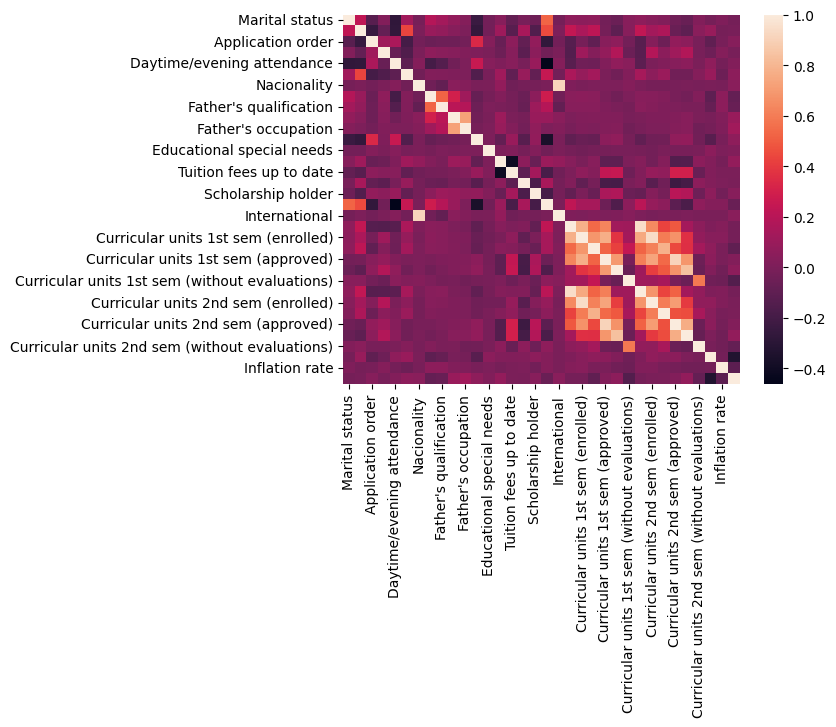

In [151]:
sns.heatmap(Corr)

<Axes: xlabel='count', ylabel='Target'>

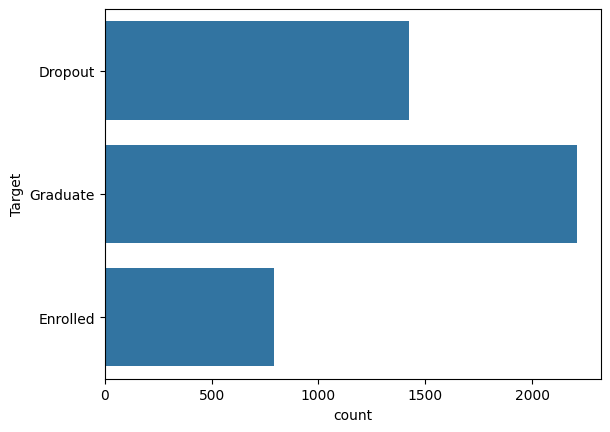

In [152]:
sns.countplot(data['Target'])

In [153]:
data.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [154]:
col=data.drop(columns=['Target'])

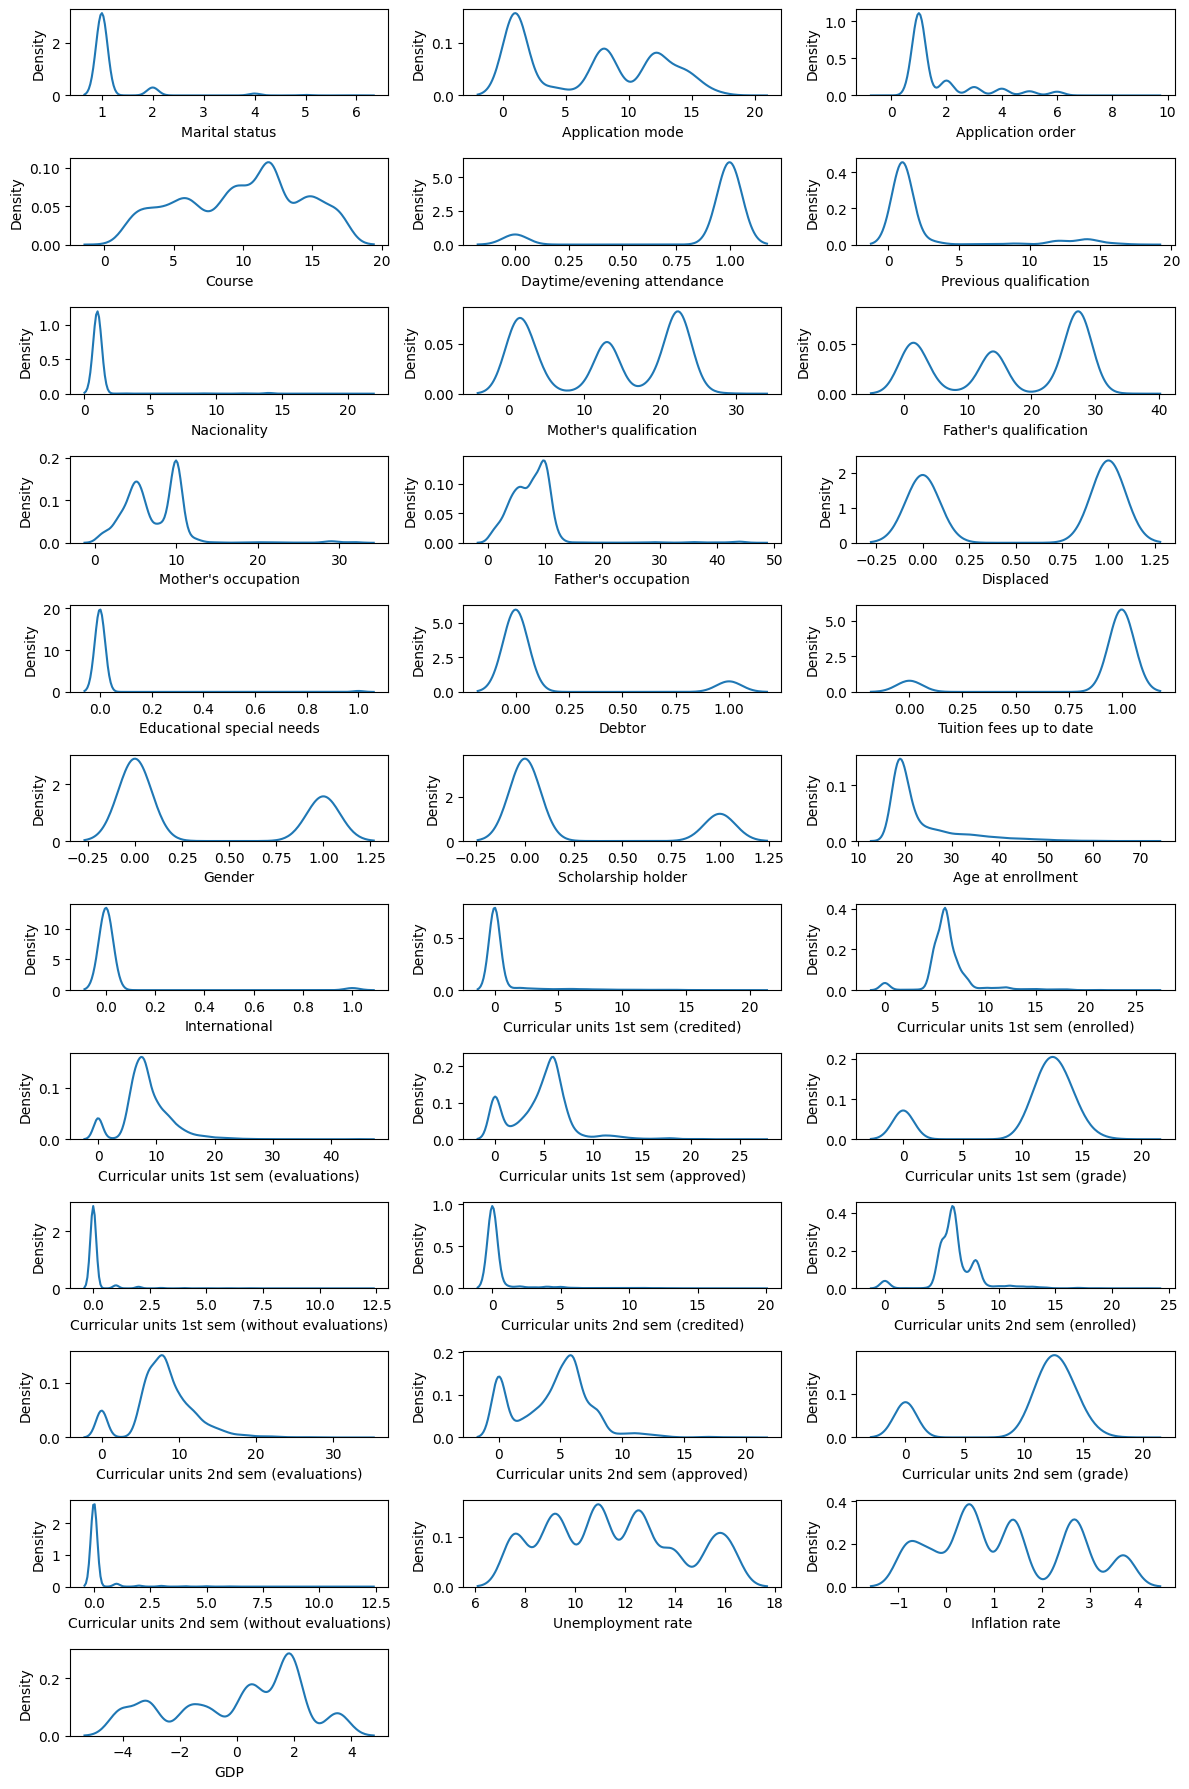

In [155]:
plt.figure(figsize=(12,18))

for index, column_name in enumerate(col.columns):
  plt.subplot(12,3,index+1)
  sns.kdeplot(data[column_name])
  plt.tight_layout()
plt.show()

In [156]:
# finding skewed data

for i in col:
  print(f'{i} : ',data[i].skew())

Marital status :  4.399764349657625
Application mode :  0.12169577066450989
Application order :  1.8810499569187527
Course :  -0.18955740705922472
Daytime/evening attendance :  -2.5072376266292378
Previous qualification :  2.405934240863601
Nacionality :  7.282730354206073
Mother's qualification :  -0.09719695465146795
Father's qualification :  -0.2917398054031348
Mother's occupation :  2.2312274952486795
Father's occupation :  4.058406733918493
Displaced :  -0.1944678977534714
Educational special needs :  9.154976343415278
Debtor :  2.4346522339392225
Tuition fees up to date :  -2.3490536625054226
Gender :  0.6212791167838527
Scholarship holder :  1.164870855478664
Age at enrollment :  2.0549883694238757
International :  6.104830144054609
Curricular units 1st sem (credited) :  4.169048768133995
Curricular units 1st sem (enrolled) :  1.6190409058476551
Curricular units 1st sem (evaluations) :  0.9766367042003191
Curricular units 1st sem (approved) :  0.7662623977563179
Curricular units

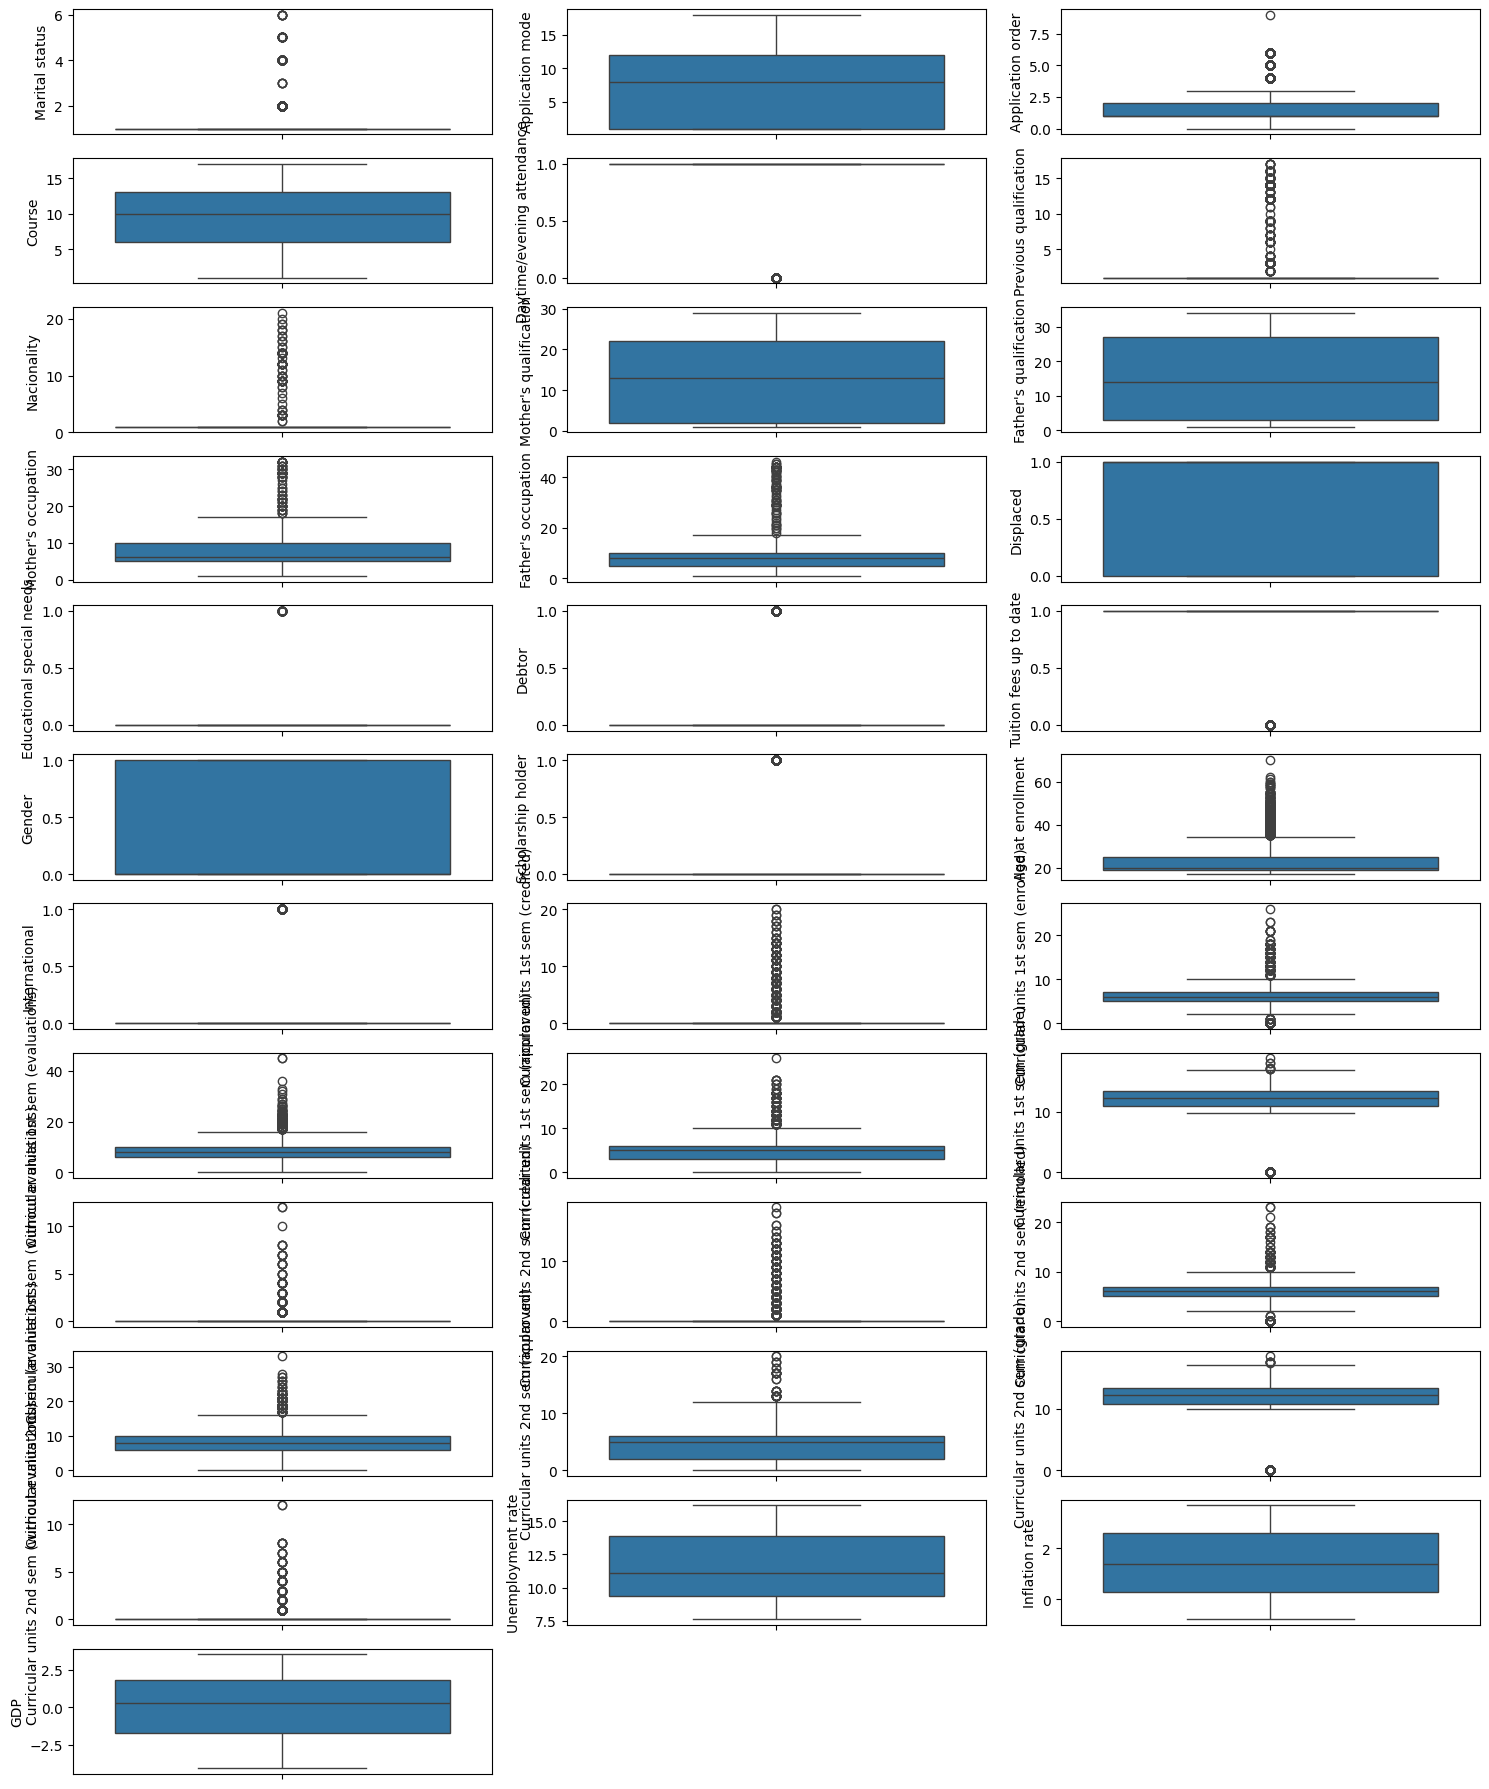

In [157]:
plt.figure(figsize=(15,18))

for index, column_name in enumerate(col.columns):
  plt.subplot(12,3,index+1)
  sns.boxplot(data[column_name])
  plt.tight_layout()
plt.show()

In [158]:
x=data.drop(columns=['Target'])
y=data['Target']

In [159]:
col

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,6,1,11,1,1,1,1,3,4,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,5,1,1,1,22,27,10,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,8,2,15,1,1,1,23,27,6,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,12,1,3,0,1,1,22,28,10,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,15,1,1,1,1,1,6,...,0,0,6,8,5,12.666667,0,15.5,2.8,-4.06
4420,1,1,2,15,1,1,19,1,1,10,...,0,0,6,6,2,11.000000,0,11.1,0.6,2.02
4421,1,1,1,12,1,1,1,22,27,10,...,0,0,8,9,1,13.500000,0,13.9,-0.3,0.79
4422,1,1,1,9,1,1,1,22,27,8,...,0,0,5,6,5,12.000000,0,9.4,-0.8,-3.12


In [160]:
# Dealing with outliers

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

for i in col:
    Q1 = x_train[i].quantile(0.25)
    Q3 = x_train[i].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    x_train[i] = np.clip(x_train[i], lower_bound, upper_bound)
    x_test[i] = np.clip(x_test[i], lower_bound, upper_bound)

In [161]:
# Encode target labels if they are strings

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test=le.transform(y_test)

In [162]:
pipeline = ImbPipeline([
    ('power_transformer', PowerTransformer(method='yeo-johnson')),
    ('smote', SMOTE(random_state=42)),
    ('logistic_regression', LogisticRegression(random_state=42))
])

pipeline.fit(x_train, y_train)

Pipeline(steps=[('power_transformer', PowerTransformer()),
                ('smote', SMOTE(random_state=42)),
                ('logistic_regression', LogisticRegression(random_state=42))])

In [163]:
y_pred_pipeline = pipeline.predict(x_test)
y_proba_pipeline = pipeline.predict_proba(x_test)

print(f"Accuracy Score (Pipeline with SMOTE and PowerTransformer): {accuracy_score(y_test, y_pred_pipeline)}")
print("Confusion Matrix (Pipeline with SMOTE and PowerTransformer):")
print(confusion_matrix(y_test, y_pred_pipeline))
print(f"F1 Score (Pipeline with SMOTE and PowerTransformer): {f1_score(y_test, y_pred_pipeline, average='weighted')}")
print(f"Precision Score (Pipeline with SMOTE and PowerTransformer): {precision_score(y_test, y_pred_pipeline, average='weighted')}")
print(f"Recall Score (Pipeline with SMOTE and PowerTransformer): {recall_score(y_test, y_pred_pipeline, average='weighted')}")
print(f"ROC AUC Score (Pipeline with SMOTE and PowerTransformer): {roc_auc_score(y_test, y_proba_pipeline, multi_class='ovr', average='weighted')}")

Accuracy Score (Pipeline with SMOTE and PowerTransformer): 0.7175141242937854
Confusion Matrix (Pipeline with SMOTE and PowerTransformer):
[[185  72  27]
 [ 25  98  36]
 [ 16  74 352]]
F1 Score (Pipeline with SMOTE and PowerTransformer): 0.7304622472409283
Precision Score (Pipeline with SMOTE and PowerTransformer): 0.7584629792804256
Recall Score (Pipeline with SMOTE and PowerTransformer): 0.7175141242937854
ROC AUC Score (Pipeline with SMOTE and PowerTransformer): 0.8856210597227705


In [164]:
print("\n--- Classification Report (Logistic Regression Pipeline) ---")
print(classification_report(y_test, y_pred_pipeline))


--- Classification Report (Logistic Regression Pipeline) ---
              precision    recall  f1-score   support

           0       0.82      0.65      0.73       284
           1       0.40      0.62      0.49       159
           2       0.85      0.80      0.82       442

    accuracy                           0.72       885
   macro avg       0.69      0.69      0.68       885
weighted avg       0.76      0.72      0.73       885



In [165]:
rf_pipeline = ImbPipeline([
    ('power_transformer', PowerTransformer(method='yeo-johnson')),
    ('smote', SMOTE(random_state=42)),
    ('random_forest', RandomForestClassifier(random_state=42))
])

print("Training RandomForest Pipeline...")
rf_pipeline.fit(x_train, y_train)

y_pred_rf_pipeline = rf_pipeline.predict(x_test)
y_proba_rf_pipeline = rf_pipeline.predict_proba(x_test)

print(f"\nAccuracy Score (RF Pipeline): {accuracy_score(y_test, y_pred_rf_pipeline)}")
print("Confusion Matrix (RF Pipeline):")
print(confusion_matrix(y_test, y_pred_rf_pipeline))
print(f"F1 Score (RF Pipeline): {f1_score(y_test, y_pred_rf_pipeline, average='weighted')}")
print(f"Precision Score (RF Pipeline): {precision_score(y_test, y_pred_rf_pipeline, average='weighted')}")
print(f"Recall Score (RF Pipeline): {recall_score(y_test, y_pred_rf_pipeline, average='weighted')}")
print(f"ROC AUC Score (RF Pipeline): {roc_auc_score(y_test, y_proba_rf_pipeline, multi_class='ovr', average='weighted')}")

Training RandomForest Pipeline...

Accuracy Score (RF Pipeline): 0.7310734463276836
Confusion Matrix (RF Pipeline):
[[193  51  40]
 [ 41  71  47]
 [ 18  41 383]]
F1 Score (RF Pipeline): 0.7298097497765392
Precision Score (RF Pipeline): 0.7310153490881324
Recall Score (RF Pipeline): 0.7310734463276836
ROC AUC Score (RF Pipeline): 0.8972019144513526


In [166]:
print("\n--- Classification Report (Random Forest Pipeline) ---")
print(classification_report(y_test, y_pred_rf_pipeline))


--- Classification Report (Random Forest Pipeline) ---
              precision    recall  f1-score   support

           0       0.77      0.68      0.72       284
           1       0.44      0.45      0.44       159
           2       0.81      0.87      0.84       442

    accuracy                           0.73       885
   macro avg       0.67      0.66      0.67       885
weighted avg       0.73      0.73      0.73       885



In [167]:
# Pipeline for GradientBoostingClassifier
gb_pipeline = ImbPipeline([
    ('power_transformer', PowerTransformer(method='yeo-johnson')),
    ('smote', SMOTE(random_state=42)),
    ('gradient_boosting', GradientBoostingClassifier(random_state=42))
])

print("\nTraining GradientBoosting Pipeline...")
gb_pipeline.fit(x_train, y_train)

y_pred_gb_pipeline = gb_pipeline.predict(x_test)
y_proba_gb_pipeline = gb_pipeline.predict_proba(x_test)

print(f"\nAccuracy Score (GB Pipeline): {accuracy_score(y_test, y_pred_gb_pipeline)}")
print("Confusion Matrix (GB Pipeline):")
print(confusion_matrix(y_test, y_pred_gb_pipeline))
print(f"F1 Score (GB Pipeline): {f1_score(y_test, y_pred_gb_pipeline, average='weighted')}")
print(f"Precision Score (GB Pipeline): {precision_score(y_test, y_pred_gb_pipeline, average='weighted')}")
print(f"Recall Score (GB Pipeline): {recall_score(y_test, y_pred_gb_pipeline, average='weighted')}")
print(f"ROC AUC Score (GB Pipeline): {roc_auc_score(y_test, y_proba_gb_pipeline, multi_class='ovr', average='weighted')}")


Training GradientBoosting Pipeline...

Accuracy Score (GB Pipeline): 0.7468926553672316
Confusion Matrix (GB Pipeline):
[[206  49  29]
 [ 39  79  41]
 [ 20  46 376]]
F1 Score (GB Pipeline): 0.7490136427063351
Precision Score (GB Pipeline): 0.7520760103771202
Recall Score (GB Pipeline): 0.7468926553672316
ROC AUC Score (GB Pipeline): 0.8941830766323652


In [168]:
print("\n--- Classification Report (Gradient Boosting Pipeline) ---")
print(classification_report(y_test, y_pred_gb_pipeline))


--- Classification Report (Gradient Boosting Pipeline) ---
              precision    recall  f1-score   support

           0       0.78      0.73      0.75       284
           1       0.45      0.50      0.47       159
           2       0.84      0.85      0.85       442

    accuracy                           0.75       885
   macro avg       0.69      0.69      0.69       885
weighted avg       0.75      0.75      0.75       885



In [169]:
# Pipeline for XGBClassifier
xg_pipeline = ImbPipeline([
    ('power_transformer', PowerTransformer(method='yeo-johnson')),
    ('smote', SMOTE(random_state=42)),
    ('xgboost', XGBClassifier(random_state=42, enable_categorical=True)) # enable_categorical for XGBoost on transformed data
])

print("\nTraining XGBoost Pipeline...")
xg_pipeline.fit(x_train, y_train)

y_pred_xg_pipeline = xg_pipeline.predict(x_test)
y_proba_xg_pipeline = xg_pipeline.predict_proba(x_test)

print(f"\nAccuracy Score (XGB Pipeline): {accuracy_score(y_test, y_pred_xg_pipeline)}")
print("Confusion Matrix (XGB Pipeline):")
print(confusion_matrix(y_test, y_pred_xg_pipeline))
print(f"F1 Score (XGB Pipeline): {f1_score(y_test, y_pred_xg_pipeline, average='weighted')}")
print(f"Precision Score (XGB Pipeline): {precision_score(y_test, y_pred_xg_pipeline, average='weighted')}")
print(f"Recall Score (XGB Pipeline): {recall_score(y_test, y_pred_xg_pipeline, average='weighted')}")
print(f"ROC AUC Score (XGB Pipeline): {roc_auc_score(y_test, y_proba_xg_pipeline, multi_class='ovr', average='weighted')}")


Training XGBoost Pipeline...

Accuracy Score (XGB Pipeline): 0.7457627118644068
Confusion Matrix (XGB Pipeline):
[[203  39  42]
 [ 45  69  45]
 [ 17  37 388]]
F1 Score (XGB Pipeline): 0.7415143614871013
Precision Score (XGB Pipeline): 0.7392779621163449
Recall Score (XGB Pipeline): 0.7457627118644068
ROC AUC Score (XGB Pipeline): 0.8901229884904842


In [170]:
print("\n--- Classification Report (XGBoost Pipeline) ---")
print(classification_report(y_test, y_pred_xg_pipeline))


--- Classification Report (XGBoost Pipeline) ---
              precision    recall  f1-score   support

           0       0.77      0.71      0.74       284
           1       0.48      0.43      0.45       159
           2       0.82      0.88      0.85       442

    accuracy                           0.75       885
   macro avg       0.69      0.68      0.68       885
weighted avg       0.74      0.75      0.74       885



In [171]:
# Pipeline for DecisionTreeClassifier
dt_pipeline = ImbPipeline([
    ('power_transformer', PowerTransformer(method='yeo-johnson')),
    ('smote', SMOTE(random_state=42)),
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])

print("\nTraining DecisionTree Pipeline...")
dt_pipeline.fit(x_train, y_train)

y_pred_dt_pipeline = dt_pipeline.predict(x_test)
y_proba_dt_pipeline = dt_pipeline.predict_proba(x_test)

print(f"\nAccuracy Score (DT Pipeline): {accuracy_score(y_test, y_pred_dt_pipeline)}")
print("Confusion Matrix (DT Pipeline):")
print(confusion_matrix(y_test, y_pred_dt_pipeline))
print(f"F1 Score (DT Pipeline): {f1_score(y_test, y_pred_dt_pipeline, average='weighted')}")
print(f"Precision Score (DT Pipeline): {precision_score(y_test, y_pred_dt_pipeline, average='weighted')}")
print(f"Recall Score (DT Pipeline): {recall_score(y_test, y_pred_dt_pipeline, average='weighted')}")
print(f"ROC AUC Score (DT Pipeline): {roc_auc_score(y_test, y_proba_dt_pipeline, multi_class='ovr', average='weighted')}")


Training DecisionTree Pipeline...

Accuracy Score (DT Pipeline): 0.6192090395480226
Confusion Matrix (DT Pipeline):
[[170  76  38]
 [ 48  64  47]
 [ 60  68 314]]
F1 Score (DT Pipeline): 0.629745405966879
Precision Score (DT Pipeline): 0.6445556391737538
Recall Score (DT Pipeline): 0.6192090395480226
ROC AUC Score (DT Pipeline): 0.7150394021145723


In [172]:
print("\n--- Classification Report (Decision Tree Pipeline) ---")
print(classification_report(y_test, y_pred_dt_pipeline))


--- Classification Report (Decision Tree Pipeline) ---
              precision    recall  f1-score   support

           0       0.61      0.60      0.60       284
           1       0.31      0.40      0.35       159
           2       0.79      0.71      0.75       442

    accuracy                           0.62       885
   macro avg       0.57      0.57      0.57       885
weighted avg       0.64      0.62      0.63       885



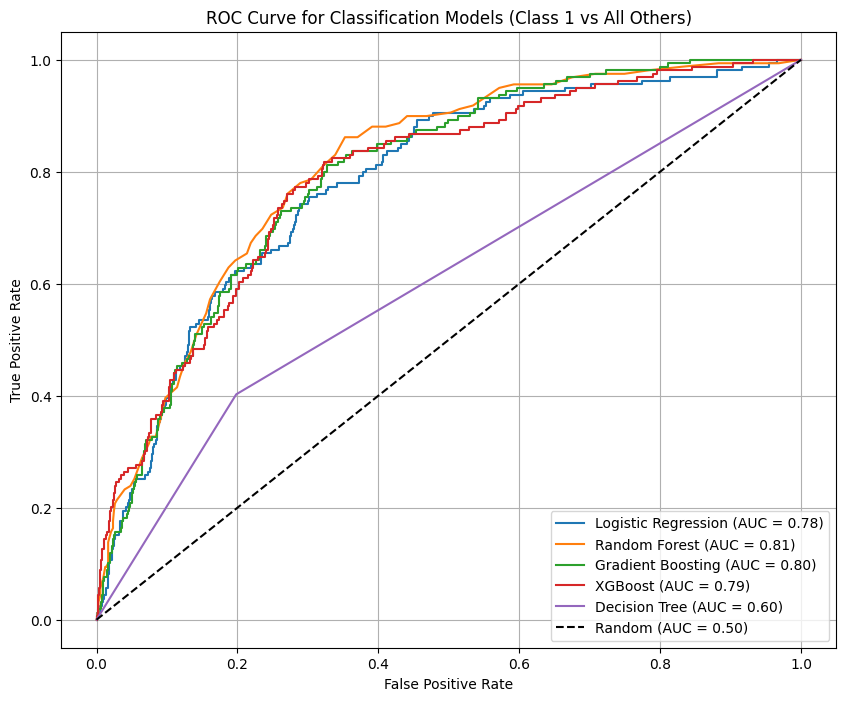

In [173]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_pipeline[:, 1], pos_label=1)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf_pipeline[:, 1], pos_label=1)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb_pipeline[:, 1], pos_label=1)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})')

# XGBoost
fpr_xg, tpr_xg, _ = roc_curve(y_test, y_proba_xg_pipeline[:, 1], pos_label=1)
roc_auc_xg = auc(fpr_xg, tpr_xg)
plt.plot(fpr_xg, tpr_xg, label=f'XGBoost (AUC = {roc_auc_xg:.2f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt_pipeline[:, 1], pos_label=1)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classification Models (Class 1 vs All Others)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()